In [2]:
import pandas as pd
import json

# Load the JSON file
dataset_path = "3000_thermal_relaxation_dataset.json"

with open(dataset_path, "r") as f:
    data = json.load(f)

df = pd.DataFrame(data)
df.dropna(inplace=True)

# Quick overview
print(df.columns)
print(df.shape)
print(df.head())

Index(['backend', 'timestamp', 'n_qubits', 'logical_n_gates',
       'logical_n_type_gates', 'logical_depth', 'physical_n_gates',
       'physical_n_type_gates', 'physical_depth', 'p_noisy', 'p_ideal',
       'kl_divergence', 'js_divergence', 'gate_props', 'qubit_props'],
      dtype='object')
(2970, 15)
   backend      timestamp  n_qubits  logical_n_gates  \
0  ibm_fez  1763512579000         5               25   
1  ibm_fez  1763517838000         5               23   
2  ibm_fez  1763517838000         5               22   
3  ibm_fez  1763518898000         5               32   
4  ibm_fez  1763518898000         5               24   

                 logical_n_type_gates  logical_depth  physical_n_gates  \
0   {'cx': 6, 'h': 9, 's': 8, 't': 2}             10                48   
1  {'cx': 10, 'h': 7, 's': 5, 't': 1}             11                42   
2  {'cx': 3, 'h': 1, 's': 8, 't': 10}              9                29   
3  {'cx': 8, 'h': 6, 's': 8, 't': 10}             17         

In [3]:
import json
from pprint import pprint
from collections import Counter



print(f"Number of samples: {len(data)}\n")

# Top-level keys
print("Top-level keys in each sample:")
if len(data) > 0:
    for k in data[0].keys():
        print(f"  - {k} ({type(data[0][k])})")
print("\n")

# Function to inspect first-level keys of nested dicts/lists
def inspect_first_level(d, max_elements=10):
    if isinstance(d, dict):
        for i, (k, v) in enumerate(d.items()):
            if i >= max_elements:
                print(f"  ... ({len(d) - max_elements} more keys)")
                break
            print(f"  - {k}: {type(v)}")
    elif isinstance(d, list):
        print(f"  list of length {len(d)}")
        if len(d) > 0 and isinstance(d[0], dict):
            print("  first dict keys:")
            inspect_first_level(d[0], max_elements=max_elements)

# Inspect nested keys in the first sample
print("Nested keys in the first sample (only first-level of nested dicts/lists):\n")
for key, value in data[0].items():
    if isinstance(value, dict) or isinstance(value, list):
        print(f"{key}:")
        inspect_first_level(value)
print("\n")

# Show only top-level fields of first sample as example
print("Top-level view of sample 0:")
pprint({k: type(v) for k, v in data[0].items()})

Number of samples: 2970

Top-level keys in each sample:
  - backend (<class 'str'>)
  - timestamp (<class 'int'>)
  - n_qubits (<class 'int'>)
  - logical_n_gates (<class 'int'>)
  - logical_n_type_gates (<class 'dict'>)
  - logical_depth (<class 'int'>)
  - physical_n_gates (<class 'int'>)
  - physical_n_type_gates (<class 'dict'>)
  - physical_depth (<class 'int'>)
  - p_noisy (<class 'dict'>)
  - p_ideal (<class 'dict'>)
  - kl_divergence (<class 'float'>)
  - js_divergence (<class 'float'>)
  - gate_props (<class 'dict'>)
  - qubit_props (<class 'dict'>)


Nested keys in the first sample (only first-level of nested dicts/lists):

logical_n_type_gates:
  - cx: <class 'int'>
  - h: <class 'int'>
  - s: <class 'int'>
  - t: <class 'int'>
physical_n_type_gates:
  - rz: <class 'int'>
  - sx: <class 'int'>
  - cx: <class 'int'>
  - measure: <class 'int'>
  - barrier: <class 'int'>
p_noisy:
  - 00000: <class 'float'>
  - 01000: <class 'float'>
  - 01010: <class 'float'>
  - 00100: <class 

In [4]:
import numpy as np
import pandas as pd

def extract_features(sample, calibration_gates = True, calibration_qubits = True, circuit_logical = True, circuit_physical = True):
    features = {}
    
    # Scalars
    features['n_qubits'] = sample['n_qubits']

    if circuit_logical :
        features['logical_n_gates'] = sample['logical_n_gates']
        features['logical_depth'] = sample['logical_depth']
        for g, count in sample['logical_n_type_gates'].items():
            features[f"logical_{g}_count"] = count
    if circuit_physical:
        features['physical_n_gates'] = sample['physical_n_gates']
        features['physical_depth'] = sample['physical_depth']
        for g, count in sample['physical_n_type_gates'].items():
            features[f"physical_{g}_count"] = count
    
    if calibration_gates:
        # Average gate error
        gate_dict = sample['gate_props']
        gate_errors = [v for v in gate_dict.get('gate_error', {}).values() if v is not None and not np.isnan(v)]
        aritys = [v - 1 for v in gate_dict.get('arity', {}).values() if v is not None and not np.isnan(v)]
        features['avg_gate_error'] = np.mean(gate_errors) if gate_errors else np.nan
        features['2_qubit_frac'] = np.mean(aritys) if aritys else np.nan
    
    if calibration_qubits:
        # Average qubit properties
        qubit_dicts = sample['qubit_props']
        T1s = [v for v in qubit_dicts.get('T1', {}).values() if v is not None and not np.isnan(v)]
        T2s = [v for v in qubit_dicts.get('T2', {}).values() if v is not None and not np.isnan(v)]
        prob_meas0_prep1 = [v for v in qubit_dicts.get('prob_meas0_prep1', {}).values() if v is not None and not np.isnan(v)]
        prob_meas1_prep0 = [v for v in qubit_dicts.get('prob_meas1_prep0', {}).values() if v is not None and not np.isnan(v)]
        readout_errors = [v for v in qubit_dicts.get('readout_error', {}).values() if v is not None and not np.isnan(v)]
        readout_lengths = [v for v in qubit_dicts.get('readout_length', {}).values() if v is not None and not np.isnan(v)]
        features['avg_T1'] = np.mean(T1s) if T1s else np.nan
        features['avg_T2'] = np.mean(T2s) if T2s else np.nan
        #features['std_T1'] = np.std(T1s) if T1s else np.nan
        #features['std_T2'] = np.std(T2s) if T2s else np.nan
        features['prob_meas0_prep1'] = np.mean(prob_meas0_prep1) if prob_meas0_prep1 else np.nan
        features['prob_meas1_prep0'] = np.mean(prob_meas1_prep0) if prob_meas1_prep0 else np.nan
        features['avg_readout_error'] = np.mean(readout_errors) if readout_errors else np.nan
        features['avg_readout_length'] = np.mean(readout_lengths) if readout_lengths else np.nan
    
    # Backend as categorical
    features['backend'] = sample['backend']
    
    # Target values
    features['kl_divergence'] = sample['kl_divergence']
    features['js_divergence'] = sample['js_divergence']
    
    return features

# Apply to all samples
df_features = pd.DataFrame([extract_features(s) for s in data])

In [5]:
data[0]['qubit_props'].keys()

dict_keys(['T1', 'T2', 'readout_error', 'prob_meas0_prep1', 'prob_meas1_prep0', 'readout_length'])

In [6]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Columns
categorical_cols = ['backend']
numeric_cols = [c for c in df_features.columns if c not in categorical_cols + ['kl_divergence','js_divergence']]

# Preprocessing pipeline
preprocessor = ColumnTransformer(transformers=[
    ('num', SimpleImputer(strategy='mean'), numeric_cols),
    ('cat', OneHotEncoder(), categorical_cols)
])

In [7]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

X = df_features.drop(['kl_divergence','js_divergence'], axis=1)
y = df_features['kl_divergence']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

pipeline = Pipeline([
    ('preprocess', preprocessor),
    ('model', RandomForestRegressor(n_estimators=200, random_state=42))
])

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print("Test RMSE:", rmse)

Test RMSE: 2.303777670950006


In [8]:
print("KL divergence range:", df_features['kl_divergence'].apply(lambda x: np.log(x+1)).min(), df_features['kl_divergence'].max())

KL divergence range: 0.002039611976634308 27.0957815407


In [9]:
kl_distribution = df_features['kl_divergence']
print("KL divergence distribution:")
print(kl_distribution.describe())


KL divergence distribution:
count    2970.000000
mean        3.036884
std         3.730595
min         0.002042
25%         0.380465
50%         1.544764
75%         4.550813
max        27.095782
Name: kl_divergence, dtype: float64


In [10]:
# Get trained preprocessor
preprocessor = pipeline.named_steps['preprocess']

# Get transformed feature names
feature_names = preprocessor.get_feature_names_out()

# Get model importances
importances = pipeline.named_steps['model'].feature_importances_

# Build series safely
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

feat_imp

num__avg_readout_error         0.486472
num__avg_gate_error            0.065008
num__prob_meas1_prep0          0.060349
num__avg_T2                    0.050298
num__logical_h_count           0.038133
num__physical_sx_count         0.037525
num__physical_n_gates          0.031956
num__physical_rz_count         0.029987
num__physical_depth            0.028689
num__avg_T1                    0.027620
num__prob_meas0_prep1          0.024212
num__logical_n_gates           0.022027
num__logical_s_count           0.019781
num__logical_t_count           0.018610
num__logical_depth             0.017655
num__logical_cx_count          0.011450
num__physical_cx_count         0.011354
cat__backend_ibm_marrakesh     0.008142
num__avg_readout_length        0.007443
cat__backend_ibm_fez           0.001572
cat__backend_ibm_torino        0.001156
num__2_qubit_frac              0.000563
num__n_qubits                  0.000000
num__physical_barrier_count    0.000000
num__physical_measure_count    0.000000


<Axes: >

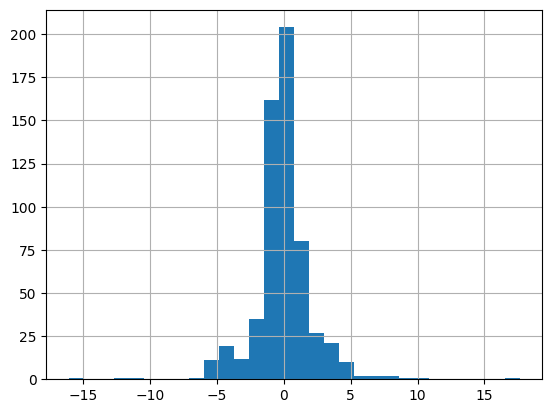

In [11]:
residual = y_test - y_pred
residual.hist(bins=30)

In [12]:
df_features.columns

Index(['n_qubits', 'logical_n_gates', 'logical_depth', 'logical_cx_count',
       'logical_h_count', 'logical_s_count', 'logical_t_count',
       'physical_n_gates', 'physical_depth', 'physical_rz_count',
       'physical_sx_count', 'physical_cx_count', 'physical_measure_count',
       'physical_barrier_count', 'avg_gate_error', '2_qubit_frac', 'avg_T1',
       'avg_T2', 'prob_meas0_prep1', 'prob_meas1_prep0', 'avg_readout_error',
       'avg_readout_length', 'backend', 'kl_divergence', 'js_divergence'],
      dtype='object')

In [13]:
def modelisation_extraction(df_features, calibration_gates=True, calibration_qubits=True, circuit_logical=True, circuit_physical=True):
    if not calibration_gates:
        df_features = df_features.drop(['avg_gate_error', '2_qubit_frac'], axis=1)
    if not calibration_qubits:
        df_features = df_features.drop(['avg_T1', 'avg_T2', 'prob_meas0_prep1', 'prob_meas1_prep0', 'avg_readout_error', 'avg_readout_length'], axis=1)
    if not circuit_logical:
        logical_cols = [col for col in df_features.columns if col.startswith('logical_')]
        df_features = df_features.drop(logical_cols, axis=1)
    if not circuit_physical:
        physical_cols = [col for col in df_features.columns if col.startswith('physical_')]
        df_features = df_features.drop(physical_cols, axis=1)
    return df_features

In [14]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt


def grid_search_modelisation(data, model, n_iterations=10):

    results = []
    df_features = pd.DataFrame([extract_features(s) for s in data])

    with tqdm(total=32*n_iterations) as pbar:

        for calibration_gates in [True, False]:
            for calibration_qubits in [True, False]:
                for circuit_logical in [True, False]:
                    for circuit_physical in [True, False]:

                        df_features_filtered = modelisation_extraction(
                            df_features,
                            calibration_gates,
                            calibration_qubits,
                            circuit_logical,
                            circuit_physical
                        )

                        X = df_features_filtered.drop(['kl_divergence','js_divergence'], axis=1)
                        y = df_features_filtered[['kl_divergence','js_divergence']]

                        for iteration in range(n_iterations):

                            X_train, X_test, y_train, y_test = train_test_split(
                                X, y, test_size=0.2
                            )

                            numeric_cols = [c for c in X.columns if c not in ['backend']]
                            categorical_cols = ['backend']

                            preprocessor = ColumnTransformer(transformers=[
                                ('num', SimpleImputer(strategy='mean'), numeric_cols),
                                ('cat', OneHotEncoder(), categorical_cols)
                            ])

                            pipeline = Pipeline([
                                ('preprocess', preprocessor),
                                ('model', model)
                            ])

                            for target in ['kl_divergence', 'js_divergence']:

                                y_train_target = y_train[target]
                                y_test_target = y_test[target]

                                pipeline.fit(X_train, y_train_target)
                                y_pred = pipeline.predict(X_test)

                                rmse = np.sqrt(mean_squared_error(y_test_target, y_pred))
                                mae = mean_absolute_error(y_test_target, y_pred)
                                r2 = r2_score(y_test_target, y_pred)
                                corr = np.corrcoef(y_test_target, y_pred)[0,1]

                                results.append({
                                    "Calibration_gates": calibration_gates,
                                    "Calibration_qubits": calibration_qubits,
                                    "Circuit_logical": circuit_logical,
                                    "Circuit_physical": circuit_physical,
                                    "Target": target,
                                    "Iteration": iteration,
                                    "RMSE": rmse,
                                    "MAE": mae,
                                    "R2": r2,
                                    "Correlation": corr
                                })

                                pbar.update(1)

    results_df = pd.DataFrame(results)

    # readable labels
    def calibration_label(row):
        if row["Calibration_gates"] and row["Calibration_qubits"]:
            return "Both"
        elif row["Calibration_gates"]:
            return "Gates"
        elif row["Calibration_qubits"]:
            return "Qubits"
        return "None"

    def circuit_label(row):
        if row["Circuit_logical"] and row["Circuit_physical"]:
            return "Both"
        elif row["Circuit_logical"]:
            return "Logical"
        elif row["Circuit_physical"]:
            return "Physical"
        return "None"

    results_df["Calibration"] = results_df.apply(calibration_label, axis=1)
    results_df["Circuit"] = results_df.apply(circuit_label, axis=1)

    # Aggregate metrics (mean and std)
    summary = (
        results_df
        .groupby(["Target","Calibration","Circuit"])
        .agg({
            "RMSE": ["mean","std"],
            "MAE": ["mean","std"],
            "R2": ["mean","std"],
            "Correlation": ["mean","std"]
        })
        .reset_index()
    )

    print(summary)

    # Boxplots for RMSE comparison
    for target in ["kl_divergence","js_divergence"]:

        subset = results_df[results_df["Target"] == target]

        sns.boxplot(
            data=subset,
            x="Calibration",
            y="RMSE",
            hue="Circuit"
        )

        plt.title(f"{target} RMSE distribution ({model.__class__.__name__})")
        plt.ylabel("RMSE")
        plt.xlabel("Calibration features")
        plt.show()

    return results_df, summary

100%|██████████| 640/640 [15:08<00:00,  1.42s/it]


           Target Calibration   Circuit      RMSE                 MAE  \
                                             mean       std      mean   
0   js_divergence        Both      Both  0.038159  0.002449  0.024082   
1   js_divergence        Both   Logical  0.037832  0.002689  0.024172   
2   js_divergence        Both      None  0.043645  0.002368  0.027681   
3   js_divergence        Both  Physical  0.037535  0.002569  0.023853   
4   js_divergence       Gates      Both  0.038752  0.002702  0.024405   
5   js_divergence       Gates   Logical  0.039871  0.002934  0.025047   
6   js_divergence       Gates      None  0.043859  0.003043  0.027965   
7   js_divergence       Gates  Physical  0.038295  0.002754  0.024388   
8   js_divergence        None      Both  0.075247  0.006210  0.039650   
9   js_divergence        None   Logical  0.076959  0.007414  0.040586   
10  js_divergence        None      None  0.074182  0.009265  0.037126   
11  js_divergence        None  Physical  0.081420  

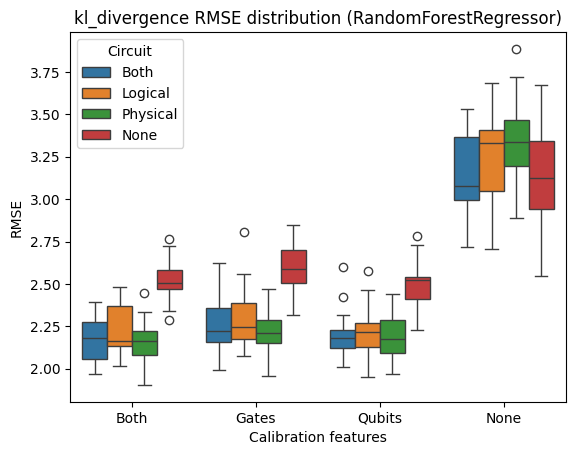

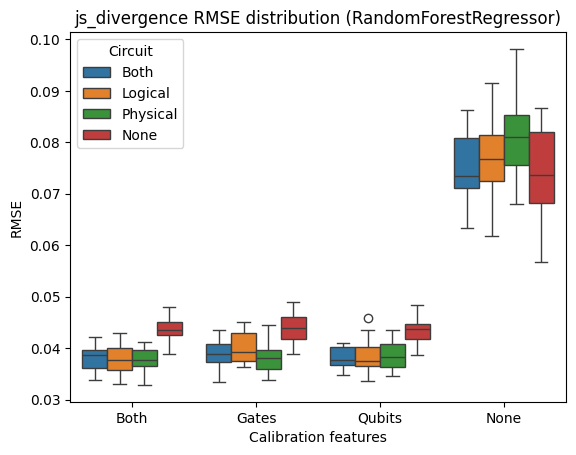

AttributeError: 'tuple' object has no attribute 'to_csv'

In [ ]:
rf_model = RandomForestRegressor(n_estimators=100)
rf_results_df, rf_summary = grid_search_modelisation(data, rf_model, n_iterations=20)
rf_results_df.to_csv(f"rf_results_{dataset_path}_100_estim.csv", index=False)

100%|██████████| 640/640 [12:36<00:00,  1.18s/it]


           Target Calibration   Circuit      RMSE                 MAE  \
                                             mean       std      mean   
0   js_divergence        Both      Both  0.055552  0.006593  0.039445   
1   js_divergence        Both   Logical  0.055826  0.006810  0.038943   
2   js_divergence        Both      None  0.043341  0.004963  0.027660   
3   js_divergence        Both  Physical  0.055687  0.007529  0.036479   
4   js_divergence       Gates      Both  0.085004  0.011862  0.052648   
5   js_divergence       Gates   Logical  0.083158  0.009477  0.048932   
6   js_divergence       Gates      None  0.074942  0.007903  0.037887   
7   js_divergence       Gates  Physical  0.079146  0.005125  0.045902   
8   js_divergence        None      Both  0.086522  0.009544  0.051670   
9   js_divergence        None   Logical  0.076245  0.007431  0.045878   
10  js_divergence        None      None  0.073201  0.007605  0.037199   
11  js_divergence        None  Physical  0.078253  

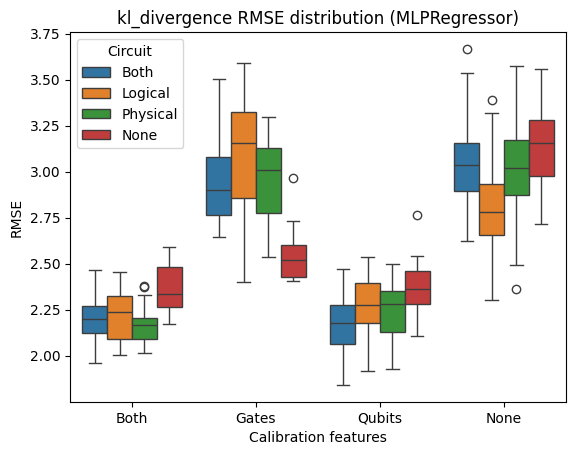

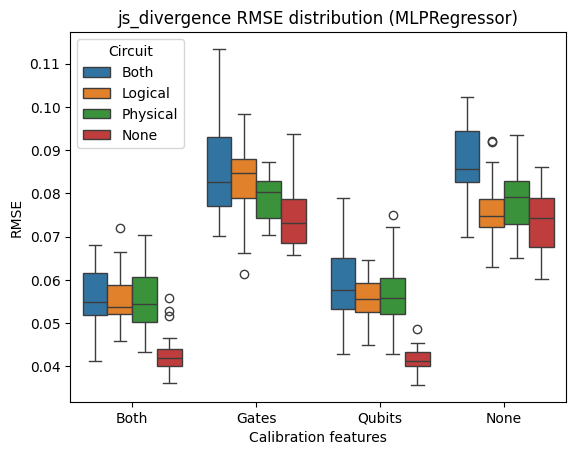

In [20]:
from sklearn.neural_network import MLPRegressor

mlp_model = MLPRegressor(hidden_layer_sizes=(64,64), max_iter=500)
mlp_results_df, mlp_summary = grid_search_modelisation(data, mlp_model, n_iterations=20)
mlp_results_df.to_csv(f"mlp_results_{dataset_path}_64_64.csv", index=False)

100%|██████████| 640/640 [00:10<00:00, 58.77it/s]


           Target Calibration   Circuit      RMSE                 MAE  \
                                             mean       std      mean   
0   js_divergence        Both      Both  0.038902  0.003107  0.026408   
1   js_divergence        Both   Logical  0.040915  0.003397  0.026840   
2   js_divergence        Both      None  0.042460  0.003219  0.027447   
3   js_divergence        Both  Physical  0.041806  0.003221  0.027307   
4   js_divergence       Gates      Both  0.050078  0.003243  0.034462   
5   js_divergence       Gates   Logical  0.051853  0.003866  0.035075   
6   js_divergence       Gates      None  0.052218  0.003326  0.036083   
7   js_divergence       Gates  Physical  0.050947  0.002944  0.034691   
8   js_divergence        None      Both  0.069822  0.006840  0.034960   
9   js_divergence        None   Logical  0.074388  0.009608  0.036007   
10  js_divergence        None      None  0.071278  0.009470  0.036756   
11  js_divergence        None  Physical  0.074803  

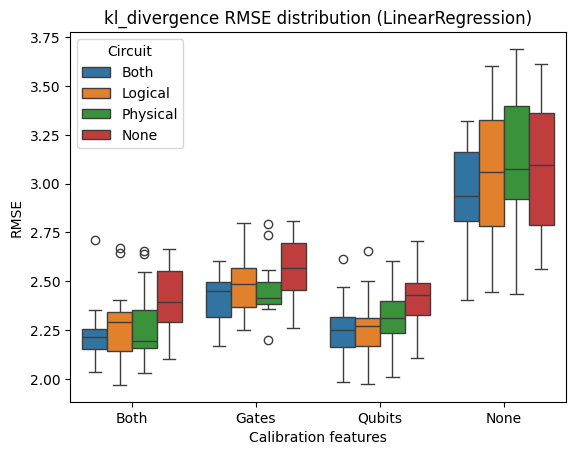

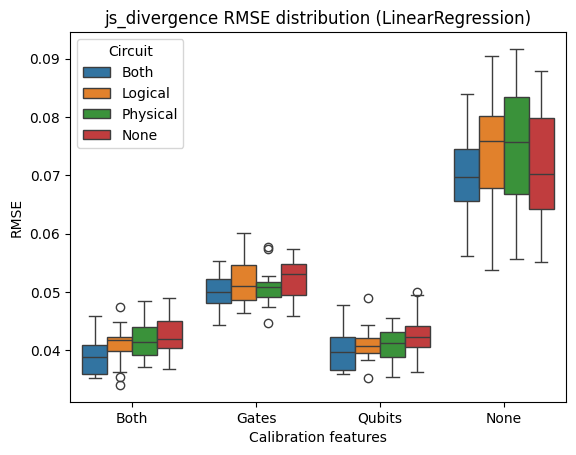

In [ ]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()
lr_results_df, lr_summary = grid_search_modelisation(data, lr_model, n_iterations=20)
lr_results_df.to_csv(f"lr_results_{dataset_path}.csv", index=False)

In [22]:
js_range = df_features['js_divergence'].min(), df_features['js_divergence'].max()
print("JS divergence range:", js_range)
kl_range = df_features['kl_divergence'].min(), df_features['kl_divergence'].max()
print("KL divergence range:", kl_range)

JS divergence range: (np.float64(0.0003448731), np.float64(0.6931471806))
KL divergence range: (np.float64(0.0020416934), np.float64(27.0957815407))
